# Entrelazado: repartir una ráfaga sin eliminar errores

**Tema 3 · Apartados 3.4 · Demostración orientativa: 8–15 minutos.**

Seguir las posiciones afectadas por una ráfaga y observar cómo se distribuyen entre varias palabras.

## Cómo experimentar

Ejecuta todo de arriba abajo. Cambia un parámetro, predice qué ocurrirá
y vuelve a ejecutar todas las celdas. En Jupyter: *Kernel → Restart Kernel and Run All Cells*;
en Colab: *Entorno de ejecución → Ejecutar todas*.

La vista HTML muestra los resultados guardados. Para recalcular se utiliza este cuaderno.
Los comentarios `#@param` permiten formularios en Colab; en Jupyter puedes editar los valores.
No se necesitan datos externos ni otros cuadernos. Las figuras y cálculos son deterministas.

## Modelo y pregunta

Disponemos $D$ palabras de $n$ símbolos como filas de una matriz. Sin entrelazado,
se transmite una fila completa detrás de otra. Con entrelazado, se lee por columnas:
primero el símbolo 1 de todas las palabras, después el símbolo 2, etc.

Marcamos $L$ instantes consecutivos como erróneos y contamos cuántos corresponden a cada
palabra al recuperar su orden. Cada casilla representa **un símbolo**, que puede ser un bit
o, por ejemplo, un símbolo Reed–Solomon. No calculamos su valor ni codificamos datos.

Suponemos que un código exterior garantiza corregir hasta $t$ símbolos erróneos por palabra.
Ese valor se da como parámetro: no se implementa su decodificador. Si una palabra supera
$t$, solo podemos decir que queda **fuera de la garantía**.

La ráfaga queda dentro de un único bloque; no se prolonga ni vuelve al principio al llegar al final.
El desentrelazado conserva el número total de errores.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

## Parámetros

Modifica un valor cada vez. Los comentarios indican unidades y rangos.

In [2]:
#@title Parámetros
profundidad = 4 #@param {type:"integer"}
longitud_palabra = 8 #@param {type:"integer"}
longitud_rafaga = 6 #@param {type:"integer"}
inicio_rafaga = 1 #@param {type:"integer"}
t = 2 #@param {type:"integer"}
tasa_simbolos = 1000 #@param {type:"integer"}
# Profundidad: 1–8; longitud: 4–16; tasa: 1–1000000 símbolos/s.
# Posiciones desde 1; no se admite que la ráfaga salga del bloque.
assert 1 <= profundidad <= 8 and 4 <= longitud_palabra <= 16
assert all(isinstance(x,int) for x in [profundidad,longitud_palabra,longitud_rafaga,inicio_rafaga,t,tasa_simbolos])
total = profundidad*longitud_palabra
assert 1 <= longitud_rafaga <= total and 1 <= inicio_rafaga <= total-longitud_rafaga+1
assert 0 <= t <= (longitud_palabra-1)//2 and 1 <= tasa_simbolos <= 1000000

## 1. De los instantes de transmisión a las palabras

Cada número es el instante en que se transmite esa casilla. Las casillas naranjas,
marcadas con ×, están afectadas por la misma ráfaga temporal en ambos casos.
La vista de la derecha ya está ordenada de nuevo por palabras en recepción.

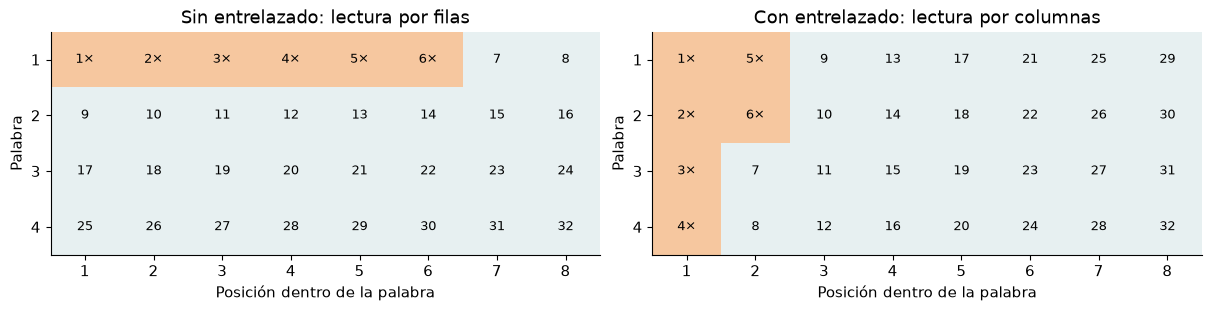

In [3]:
from matplotlib.colors import ListedColormap
orden_directo = np.arange(1,total+1).reshape(profundidad,longitud_palabra)
orden_entrelazado = np.arange(1,total+1).reshape(longitud_palabra,profundidad).T
final = inicio_rafaga+longitud_rafaga
errores_directo = (orden_directo >= inicio_rafaga) & (orden_directo < final)
errores_entrelazado = (orden_entrelazado >= inicio_rafaga) & (orden_entrelazado < final)
fig, axes = plt.subplots(1,2,figsize=(12,max(3,profundidad*.6)),layout="constrained")
for ax,orden,errores,titulo in zip(axes,[orden_directo,orden_entrelazado],
        [errores_directo,errores_entrelazado],["Sin entrelazado: lectura por filas","Con entrelazado: lectura por columnas"]):
    ax.imshow(errores,cmap=ListedColormap(["#e7f0f1","#f6c79f"]),vmin=0,vmax=1,aspect="auto")
    for i in range(profundidad):
        for j in range(longitud_palabra):
            ax.text(j,i,str(orden[i,j])+("×" if errores[i,j] else ""),ha="center",va="center",fontsize=9)
    ax.set(xticks=range(longitud_palabra),xticklabels=range(1,longitud_palabra+1),
           yticks=range(profundidad),yticklabels=range(1,profundidad+1),
           xlabel="Posición dentro de la palabra",ylabel="Palabra",title=titulo)
plt.show()

## 2. El recuento que importa al código exterior

Comparamos el número de errores por palabra con la capacidad correctora $t$.
Aumentar $D$ reparte una ráfaga entre más palabras, pero también exige reunir más símbolos.
El tiempo $Dn/f_s$ mostrado es el necesario para reunir un bloque a tasa $f_s$;
**no es una fórmula universal del retardo total** del transmisor y receptor.

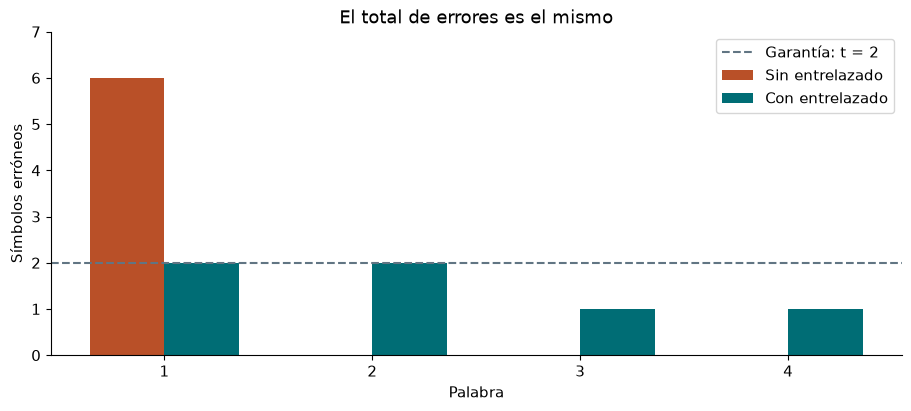

Total de errores: 6 en ambos casos.
Palabras fuera de la garantía: 1 sin entrelazado; 0 con entrelazado.
Bloque: 32 símbolos; tiempo para reunirlo: 32.00 ms.
Máximo con entrelazado: 2 errores por palabra.


In [4]:
cuenta_directa = errores_directo.sum(axis=1)
cuenta_entrelazada = errores_entrelazado.sum(axis=1)
posiciones = np.arange(profundidad)+1
fig, ax = plt.subplots(figsize=(9,4),layout="constrained")
ax.bar(posiciones-.18,cuenta_directa,width=.36,color="#b95028",label="Sin entrelazado")
ax.bar(posiciones+.18,cuenta_entrelazada,width=.36,color="#006d75",label="Con entrelazado")
ax.axhline(t,ls="--",color="#617583",label=f"Garantía: t = {t}")
ax.set(xticks=posiciones,xlabel="Palabra",ylabel="Símbolos erróneos",title="El total de errores es el mismo")
ax.set_ylim(0,max(t,cuenta_directa.max(),cuenta_entrelazada.max())+1)
ax.legend(); plt.show()
print(f"Total de errores: {cuenta_directa.sum()} en ambos casos.")
print(f"Palabras fuera de la garantía: {np.sum(cuenta_directa > t)} sin entrelazado; {np.sum(cuenta_entrelazada > t)} con entrelazado.")
print(f"Bloque: {total} símbolos; tiempo para reunirlo: {1000*total/tasa_simbolos:.2f} ms.")
print(f"Máximo con entrelazado: {cuenta_entrelazada.max()} errores por palabra.")

## Antes de mirar la explicación

1. Con los valores originales, ¿cuántos errores tiene cada palabra antes y después de entrelazar?
2. Cambia la profundidad a 1. ¿Qué ocurre?
3. Con profundidad 4, t = 2 e inicio 1, prueba ráfagas de 8 y 9 símbolos.
4. ¿Cambiar la tasa de símbolos cambia la distribución de errores de este modelo?

## Explicación de lo observado

1. Sin entrelazado: [6, 0, 0, 0]. Con entrelazado: [2, 2, 1, 1]. Los seis errores
   siguen existiendo, pero todas las palabras quedan dentro de la garantía $t=2$ en el segundo caso.
2. Con una sola fila ambos órdenes son iguales; no hay reparto entre palabras.
3. Una ráfaga de 8 se distribuye [2, 2, 2, 2]. Una de 9 se distribuye [3, 2, 2, 2]:
   ya no todas las palabras están protegidas por la garantía. En este entrelazador,
   una ráfaga de L símbolos afecta como máximo a $\lceil L/D\rceil$ símbolos de una palabra.
4. No: aquí la ráfaga se especifica en número de símbolos. Solo cambia el tiempo de llenado.
   Si fijásemos su duración en segundos, cambiar la tasa también cambiaría cuántos símbolos afecta.

No se añaden símbolos de redundancia y no se corrige ninguno en este experimento.
Tampoco se demuestra que los errores pasen a ser estadísticamente independientes.

## Comprobación del modelo

Comprobamos identidades y casos conocidos; estas celdas no sustituyen la interpretación.

In [5]:
assert cuenta_directa.sum() == cuenta_entrelazada.sum() == longitud_rafaga
assert sorted(orden_entrelazado.ravel()) == list(range(1,total+1))
assert cuenta_entrelazada.max() == int(np.ceil(longitud_rafaga/profundidad))
assert cuenta_entrelazada.max()-cuenta_entrelazada.min() <= 1
if profundidad == 1:
    assert np.array_equal(errores_directo,errores_entrelazado)
print("Conservación de errores, orden y reparto de la ráfaga comprobados.")

Conservación de errores, orden y reparto de la ráfaga comprobados.


## Referencias

Ejemplo y código propios para TDI.

- TDI, tema 3, apartados 3.4: «Entrelazado de bloques».
- J. G. Proakis y M. Salehi, *Digital Communications*, 5.ª ed., McGraw-Hill, 2008: codificación de canal.
- Los supuestos y las derivaciones particulares de este experimento se explican en «Modelo y pregunta».